In [1]:
# retrieving functions from lindbladian.ipnyb
%run '/home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb'

Note: you may need to restart the kernel to use updated packages.
  Using cached scienceplots-2.2.2-py3-none-any.whl.metadata (14 kB)
Using cached scienceplots-2.2.2-py3-none-any.whl (33 kB)
Note: you may need to restart the kernel to use updated packages.
[NbConvertApp] WARNING | pattern 'lindbladian.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Appl

In [2]:
J = sp.Symbol("J", real=True, positive=True)
epsilon  = sp.Symbol("epsilon", real=True, positive=True)
gamma = sp.Symbol("Gamma", real=True, positive=True)
delta = sp.Symbol("delta", real=True, positive=True)
Delta1, Delta2, Delta3  = sp.symbols("Delta1 Delta2 Delta3", real=True, positive=True)
Delta31, Delta32, Delta21 = sp.symbols("Delta31 Delta32 Delta21", real=True, positive=True)
t = sp.Symbol("t", real=True, positive=True)


# n=4

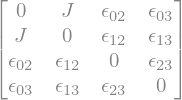

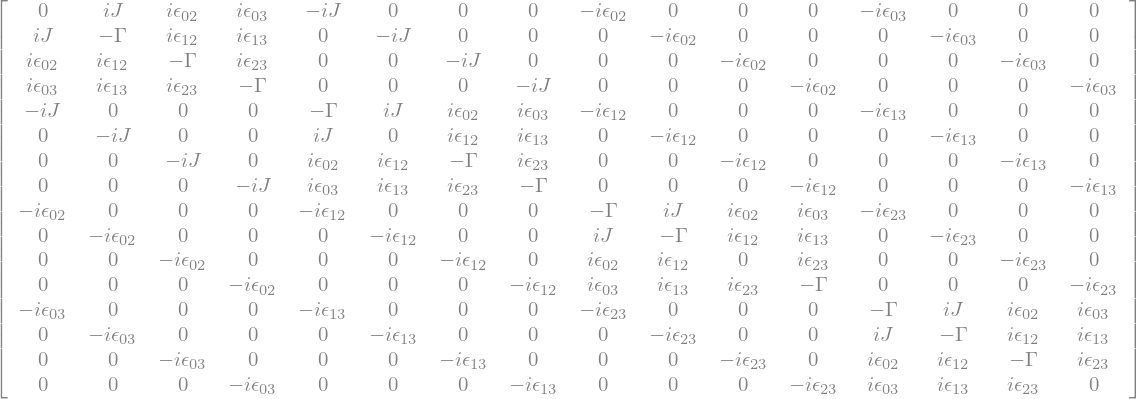

In [10]:
'''H = sp.Matrix([[0, J, epsilon, epsilon],
               [J, 0, epsilon, epsilon],
               [epsilon, epsilon, 0, epsilon],
               [epsilon, epsilon, epsilon, 0]])'''
N=4
H = sp.Matrix(N, N, lambda i,j : J if ({i,j}=={0,1}) else 0) + sp.Matrix(N, N, lambda i,j : sp.Symbol(f"epsilon_{i if i<j else j}{j if i<j else i}") if ({i,j}!={0,1} and (i!=0 or j!=0) and i!=j) else 0)

# building lindblad jump operators
L_operators = [sp.Matrix(N,N, lambda i,j: 1 if i==k and j==k else 0) for k in range(N)]

# building lindbladian
L, rho = lindbladian(N, output=False, degenerate=False, H=H, L_operators=L_operators)

# setting all dephasing constants to the same constant gamma
L = L.subs({sp.Symbol(f"Gamma_{i}", real=True, nonnegative=True):gamma for i in range(N)})

display(H)
display(L)

In [117]:
def replace(text, dic):
    out = text
    for key, val in dic.items():
        out = out.replace(key, val)
    return out

replace(mathematica_code(L).replace("Gamma","Γ"), {f"epsilon_{i}{j}" : f"Subscript[ϵ,{i},{j}]" for j in range(N) for i in range(j)})

'{{0, I*J, I*Subscript[ϵ,0,2], I*Subscript[ϵ,0,3], -I*J, 0, 0, 0, -I*Subscript[ϵ,0,2], 0, 0, 0, -I*Subscript[ϵ,0,3], 0, 0, 0}, {I*J, -Γ, I*Subscript[ϵ,1,2], I*Subscript[ϵ,1,3], 0, -I*J, 0, 0, 0, -I*Subscript[ϵ,0,2], 0, 0, 0, -I*Subscript[ϵ,0,3], 0, 0}, {I*Subscript[ϵ,0,2], I*Subscript[ϵ,1,2], -Γ, I*Subscript[ϵ,2,3], 0, 0, -I*J, 0, 0, 0, -I*Subscript[ϵ,0,2], 0, 0, 0, -I*Subscript[ϵ,0,3], 0}, {I*Subscript[ϵ,0,3], I*Subscript[ϵ,1,3], I*Subscript[ϵ,2,3], -Γ, 0, 0, 0, -I*J, 0, 0, 0, -I*Subscript[ϵ,0,2], 0, 0, 0, -I*Subscript[ϵ,0,3]}, {-I*J, 0, 0, 0, -Γ, I*J, I*Subscript[ϵ,0,2], I*Subscript[ϵ,0,3], -I*Subscript[ϵ,1,2], 0, 0, 0, -I*Subscript[ϵ,1,3], 0, 0, 0}, {0, -I*J, 0, 0, I*J, 0, I*Subscript[ϵ,1,2], I*Subscript[ϵ,1,3], 0, -I*Subscript[ϵ,1,2], 0, 0, 0, -I*Subscript[ϵ,1,3], 0, 0}, {0, 0, -I*J, 0, I*Subscript[ϵ,0,2], I*Subscript[ϵ,1,2], -Γ, I*Subscript[ϵ,2,3], 0, 0, -I*Subscript[ϵ,1,2], 0, 0, 0, -I*Subscript[ϵ,1,3], 0}, {0, 0, 0, -I*J, I*Subscript[ϵ,0,3], I*Subscript[ϵ,1,3], I*Subscript[ϵ,2,3

In [120]:
", ".join([f"Subscript[ϵ,{i},{j}] -> Subscript[ϵ,{i},{j}] * t" for j in range(N) for i in range(j)])

'Subscript[ϵ,0,1] -> Subscript[ϵ,0,1] * t, Subscript[ϵ,0,2] -> Subscript[ϵ,0,2] * t, Subscript[ϵ,1,2] -> Subscript[ϵ,1,2] * t, Subscript[ϵ,0,3] -> Subscript[ϵ,0,3] * t, Subscript[ϵ,1,3] -> Subscript[ϵ,1,3] * t, Subscript[ϵ,2,3] -> Subscript[ϵ,2,3] * t'

<>:2: SyntaxWarning: invalid escape sequence '\['
<>:8: SyntaxWarning: invalid escape sequence '\['
<>:2: SyntaxWarning: invalid escape sequence '\['
<>:8: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_261/2165015596.py:2: SyntaxWarning: invalid escape sequence '\['
  -((J^2*(\[CapitalGamma]^2 - 2*Subscript[\[Epsilon], 2, 3]^2) + 2*Sqrt[-(J^2*\[CapitalGamma]^2*(Subscript[\[Epsilon], 0, 2]*Subscript[\[Epsilon], 1, 2] - Subscript[\[Epsilon], 0, 3]*Subscript[\[Epsilon], 1, 3])^2) +
/tmp/ipykernel_261/2165015596.py:8: SyntaxWarning: invalid escape sequence '\['
  evals_approx = parse_mathematica(replace(evals_string, {f"Subscript[\\[Epsilon], {i}, {j}]" : f"epsilon{i}{j}"  for j in range(N) for i in range(j)}).replace("\[CapitalGamma]", "Gamma")).subs({sp.Symbol("J"): J, sp.Symbol("Gamma"):gamma})


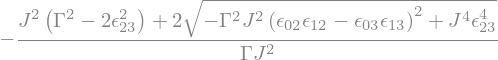

In [116]:
evals_string = '''
-((J^2*(\[CapitalGamma]^2 - 2*Subscript[\[Epsilon], 2, 3]^2) + 2*Sqrt[-(J^2*\[CapitalGamma]^2*(Subscript[\[Epsilon], 0, 2]*Subscript[\[Epsilon], 1, 2] - Subscript[\[Epsilon], 0, 3]*Subscript[\[Epsilon], 1, 3])^2) + 
      J^4*Subscript[\[Epsilon], 2, 3]^4])/(J^2*\[CapitalGamma]))
'''



evals_approx = parse_mathematica(replace(evals_string, {f"Subscript[\\[Epsilon], {i}, {j}]" : f"epsilon{i}{j}"  for j in range(N) for i in range(j)}).replace("\[CapitalGamma]", "Gamma")).subs({sp.Symbol("J"): J, sp.Symbol("Gamma"):gamma})


display(evals_approx)

evals_approx.subs({f"epsilon{i}{j}" : epsilon  for j in range(N) for i in range(j)}).simplify(deep=True)

evals_approx.subs({f"epsilon{i}{j}" : 1e-4  for j in range(N) for i in range(j)}).subs(gamma,1e6).simplify(deep=True)


# n=5

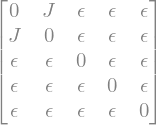

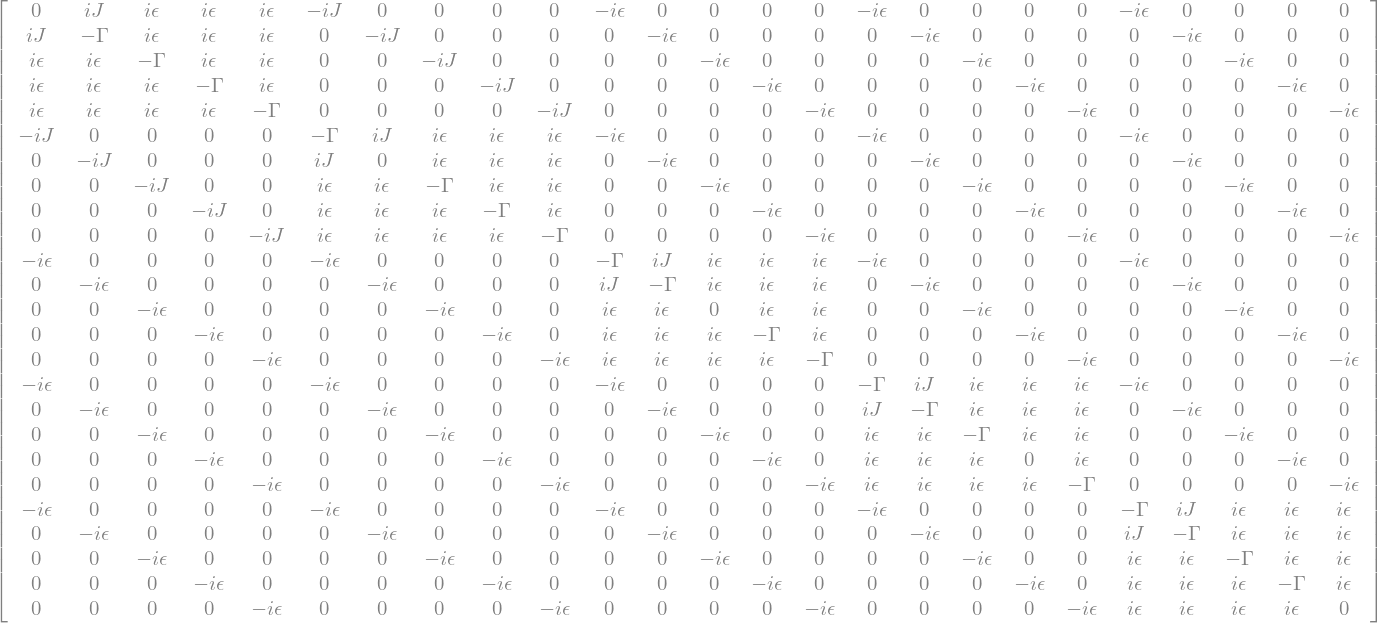

In [13]:
H = sp.Matrix([[0, J, epsilon, epsilon, epsilon], 
               [J, 0, epsilon, epsilon, epsilon], 
               [epsilon, epsilon, 0, epsilon, epsilon], 
               [epsilon, epsilon, epsilon, 0, epsilon], 
               [epsilon, epsilon, epsilon, epsilon, 0]])


L, rho = lindbladian(5, output=False, degenerate=False, H=H)

# dephasing
L = L.subs({sp.Symbol(f"Gamma_{i}→{i}", real=True, nonnegative=True): gamma for i in range(64)})

# no population transitions
L = L.subs({sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True):0 if i!=j else sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True) for i in range(64) for j in range(64)})

# writing in terms of site energy differences
L = L.subs({Delta3-Delta1:Delta31,Delta3-Delta2:Delta32, Delta2-Delta1:Delta21})

display(H)
display(L)

In [14]:
mathematica_code(L).replace("Gamma","Γ").replace("epsilon", "ϵ")

'{{0, I*J, I*ϵ, I*ϵ, I*ϵ, -I*J, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0}, {I*J, -Γ, I*ϵ, I*ϵ, I*ϵ, 0, -I*J, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0}, {I*ϵ, I*ϵ, -Γ, I*ϵ, I*ϵ, 0, 0, -I*J, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0}, {I*ϵ, I*ϵ, I*ϵ, -Γ, I*ϵ, 0, 0, 0, -I*J, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0}, {I*ϵ, I*ϵ, I*ϵ, I*ϵ, -Γ, 0, 0, 0, 0, -I*J, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ}, {-I*J, 0, 0, 0, 0, -Γ, I*J, I*ϵ, I*ϵ, I*ϵ, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0}, {0, -I*J, 0, 0, 0, I*J, 0, I*ϵ, I*ϵ, I*ϵ, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0}, {0, 0, -I*J, 0, 0, I*ϵ, I*ϵ, -Γ, I*ϵ, I*ϵ, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0}, {0, 0, 0, -I*J, 0, I*ϵ, I*ϵ, I*ϵ, -Γ, I*ϵ, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0}, {0, 0, 0, 0, -I*J, I*ϵ, I*ϵ, I*ϵ, I*ϵ, -Γ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ}, {-I*ϵ, 0, 0, 0, 0, -

<>:2: SyntaxWarning: invalid escape sequence '\['
<>:2: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_192/2719510355.py:2: SyntaxWarning: invalid escape sequence '\['
  (-10*\[CapitalGamma]*\[Epsilon]^2)/(J^2 + \[CapitalGamma]^2)


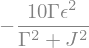

++++++++++++++++++++++++++++++


In [15]:
evals_string = '''
(-10*\[CapitalGamma]*\[Epsilon]^2)/(J^2 + \[CapitalGamma]^2)
'''

evals_approx = [parse_mathematica(evals_string.replace(r"\[CapitalGamma]", "Gamma").replace(r"\[Epsilon]", "epsilon"))]

evals_approx = [i.subs({sp.Symbol("Gamma"): gamma, sp.Symbol("epsilon"): epsilon, sp.Symbol("J"): J}) for i in evals_approx]


for i in evals_approx:
    display(i)
    print("++++++++++++++++++++++++++++++")

    

# n=6

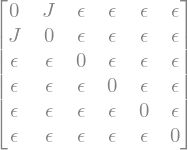

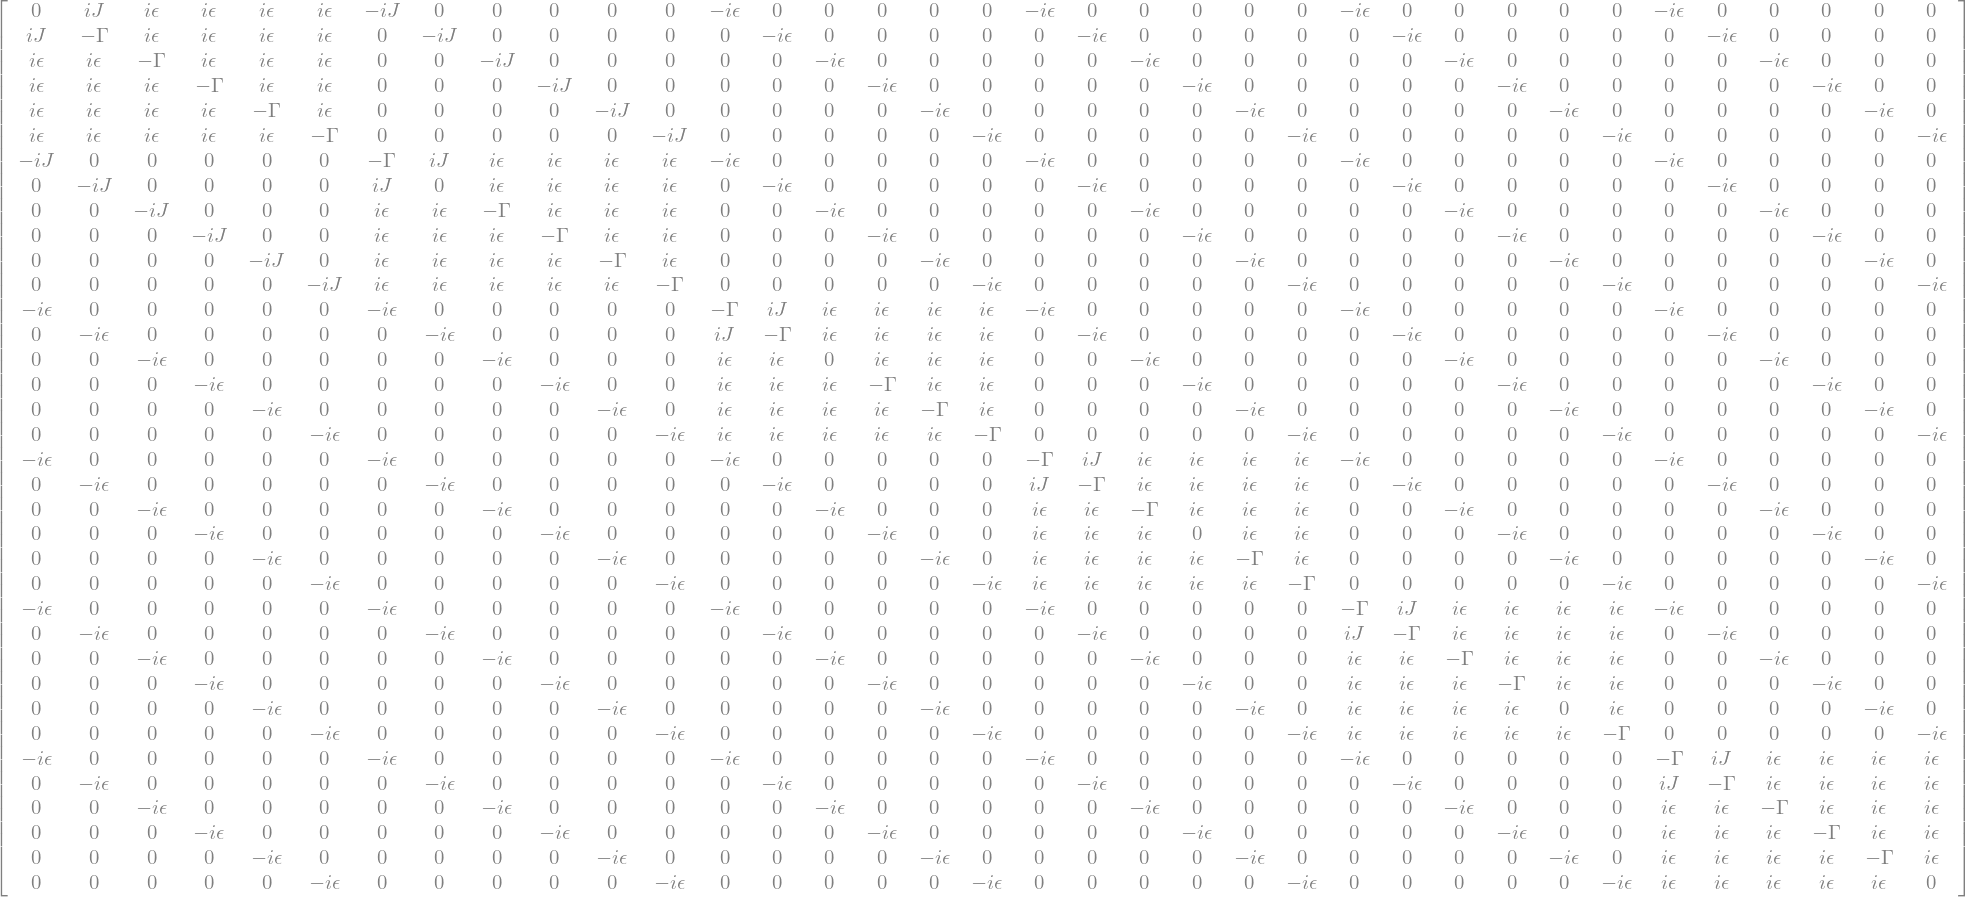

In [19]:
H = sp.Matrix([[0, J, epsilon, epsilon, epsilon, epsilon], 
               [J, 0, epsilon, epsilon, epsilon, epsilon], 
               [epsilon, epsilon, 0, epsilon, epsilon, epsilon], 
               [epsilon, epsilon, epsilon, 0, epsilon, epsilon], 
               [epsilon, epsilon, epsilon, epsilon, 0, epsilon],
               [epsilon, epsilon, epsilon, epsilon, epsilon, 0]])


L, rho = lindbladian(6, output=False, degenerate=False, H=H)

# dephasing
L = L.subs({sp.Symbol(f"Gamma_{i}→{i}", real=True, nonnegative=True): gamma for i in range(64)})

# no population transitions
L = L.subs({sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True):0 if i!=j else sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True) for i in range(64) for j in range(64)})


display(H)
display(L)

In [20]:
mathematica_code(L).replace("Gamma","Γ").replace("epsilon", "ϵ")

'{{0, I*J, I*ϵ, I*ϵ, I*ϵ, I*ϵ, -I*J, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0}, {I*J, -Γ, I*ϵ, I*ϵ, I*ϵ, I*ϵ, 0, -I*J, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0}, {I*ϵ, I*ϵ, -Γ, I*ϵ, I*ϵ, I*ϵ, 0, 0, -I*J, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0}, {I*ϵ, I*ϵ, I*ϵ, -Γ, I*ϵ, I*ϵ, 0, 0, 0, -I*J, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0}, {I*ϵ, I*ϵ, I*ϵ, I*ϵ, -Γ, I*ϵ, 0, 0, 0, 0, -I*J, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0}, {I*ϵ, I*ϵ, I*ϵ, I*ϵ, I*ϵ, -Γ, 0, 0, 0, 0, 0, -I*J, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ}, {-I*J, 0, 0, 0, 0, 0, -Γ, I*J, I*ϵ, I*ϵ, I*ϵ, I*ϵ, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0}, {0, -I*J, 0, 0, 0, 0, I*J, 0, I*ϵ, I*ϵ, I*ϵ, I*

In [4]:
import numpy as np
a = np.arange(1,10,1)

def f(x):
    return x**2

print(f(a))

[ 1  4  9 16 25 36 49 64 81]


# perturbation theory

reference paper: https://arxiv.org/pdf/1311.3227

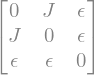

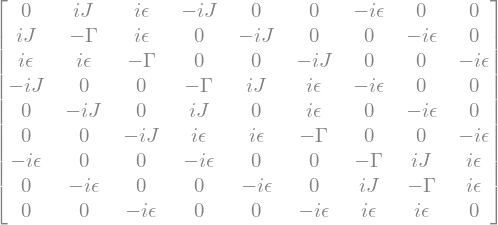

In [99]:
H = sp.Matrix([[0, J, epsilon],
               [J, 0, epsilon],
               [epsilon, epsilon, 0]])


L, rho = lindbladian(3, output=False, degenerate=False, H=H)

# dephasing
L = L.subs({sp.Symbol(f"Gamma_{i}→{i}", real=True, nonnegative=True): gamma for i in range(64)})

# no population transitions
L = L.subs({sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True):0 if i!=j else sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True) for i in range(64) for j in range(64)})

# writing in terms of site energy differences
L = L.subs({Delta3-Delta1:Delta31,Delta3-Delta2:Delta32, Delta2-Delta1:Delta21})

display(H)
display(L)

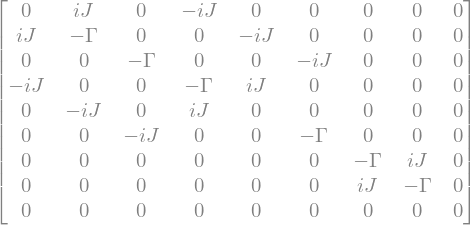

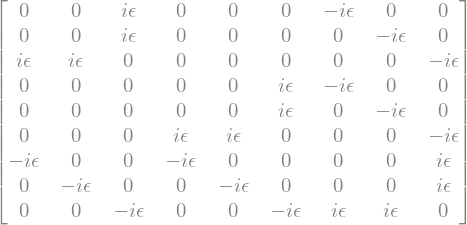

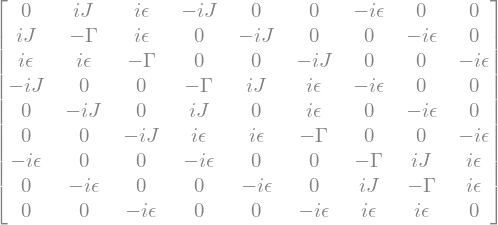

In [52]:
N = 3

# building matrices
H0 = sp.Matrix(N, N, lambda i,j : J if ({i,j}=={0,1}) else 0)
#V = sp.Matrix(N, N, lambda i,j : epsilon*sp.Symbol(f"epsilon_{i if i<j else j}{j if i<j else i}") if ({i,j}!={0,1} and (i!=0 or j!=0) and i!=j) else 0)
V = sp.Matrix(N, N, lambda i,j : sp.Symbol(f"epsilon", real=True) if ({i,j}!={0,1} and (i!=0 or j!=0) and i!=j) else 0)

# building lindblad jump operators
L_operators = [sp.Matrix(N,N, lambda i,j: 1 if i==k and j==k else 0) for k in range(N)]

# building lindbladians
L0, _ = lindbladian(N, output=False, degenerate=False, H=H0, L_operators=L_operators)
L1, _ = lindbladian(N, output=False, degenerate=False, H=V, dissipative=False)

# setting all dephasing constants to the same constant gamma
L0 = L0.subs({sp.Symbol(f"Gamma_{i}", real=True, nonnegative=True):gamma for i in range(N)})



display(L0)
display(L1)
display(L0+L1)


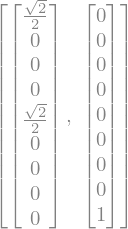

In [53]:
nullspace = [n/n.norm() for n in L0.nullspace()]
nullspace

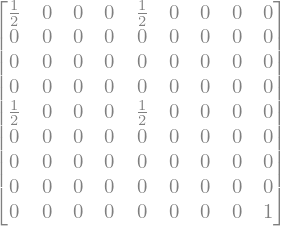

In [54]:
P = sp.Add(*[  u*u.transpose() for u in nullspace  ])
P

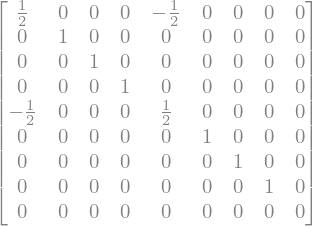

In [55]:
Q = sp.eye(sp.shape(P)[0]) - P
Q

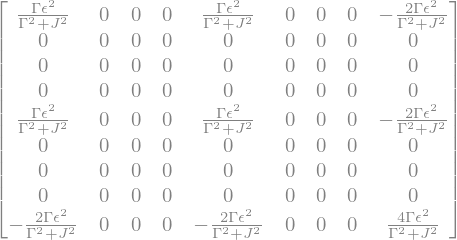

In [56]:
Leff = -1*(Q*L1*P).conjugate().transpose()*(Q*L0*Q).pinv()*Q*L1*P
Leff.applyfunc(sp.simplify)

In [77]:
Leff.eigenvals()

KeyboardInterrupt: 

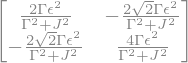

In [57]:
Leff_red = sp.Matrix(N-1, N-1, lambda i,j: (nullspace[i].transpose().conjugate()*Leff*nullspace[j])[0]).applyfunc(lambda expr: expr.simplify().apart(gamma))

Leff_red

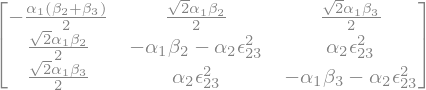

In [125]:
alpha1, alpha2, alpha3 = sp.symbols("alpha1 alpha2 alpha3")
beta1, beta2, beta3, beta4, beta5 = sp.symbols("beta_1 beta_2 beta_3 beta_4 beta5")

Leff_red.subs({ gamma*epsilon**2 / (gamma**2 + J**2) : alpha1/2 , 2*epsilon**2 / gamma : alpha2 ,  -2*alpha1-(N-3)*alpha2 : alpha3}).subs({sp.Symbol(f"epsilon_0{i}")**2 + sp.Symbol(f"epsilon_1{i}")**2 : sp.Symbol(f"beta_{i}") for i in range(N)})


In [117]:
Leff_red.subs({ gamma*epsilon**2 / (gamma**2 + J**2) : alpha1/2 , 2*epsilon**2 / gamma : alpha2 ,  -2*alpha1-(N-3)*alpha2 : alpha3}).subs({sp.Symbol(f"epsilon_0{i}")**2 + sp.Symbol(f"epsilon_1{i}")**2 : sp.Symbol(f"beta_{i}") for i in range(N)}).eigenvals()




KeyboardInterrupt: 

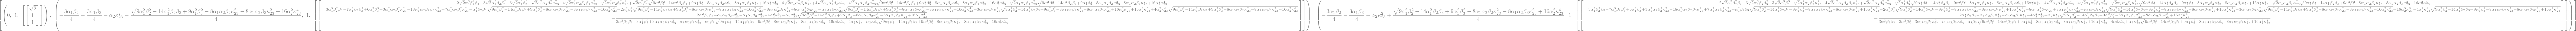

In [53]:
evecs = Leff_red.subs({ gamma*epsilon**2 / (gamma**2 + J**2) : alpha1/2 , 2*epsilon**2 / gamma : alpha2 ,  -2*alpha1-(N-3)*alpha2 : alpha3}).subs({sp.Symbol(f"kappa_0{i}")**2 + sp.Symbol(f"kappa_1{i}")**2 : sp.Symbol(f"beta_{i}") for i in range(N)}).eigenvects()
evecs

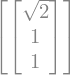

-----------------------------------


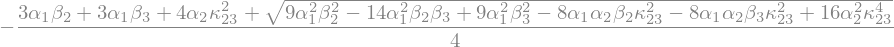

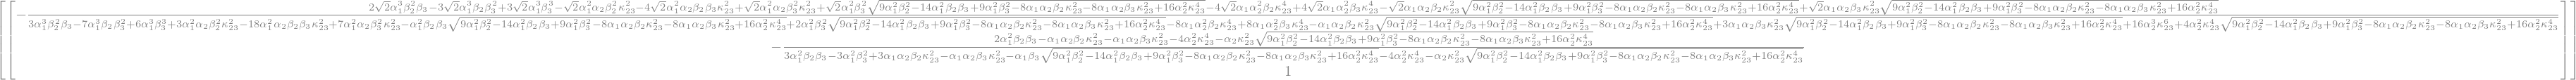

-----------------------------------


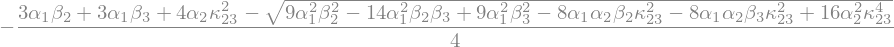

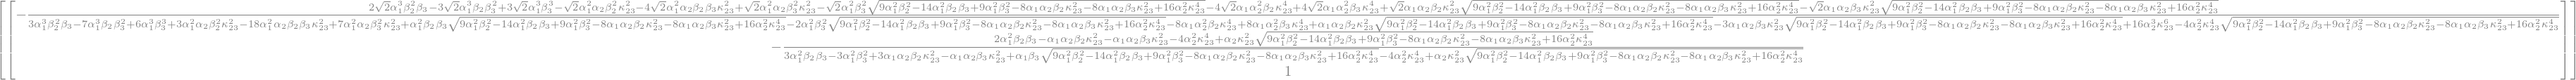

-----------------------------------


In [56]:
for evalue, multiplicity, evectors in evecs:
    display(evalue.factor(deep=True))
    #display(evalue.apart(gamma))
    display(multiplicity)
    display(evectors)
    print("-----------------------------------")

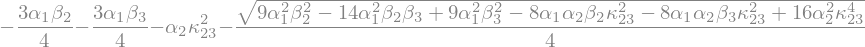

In [71]:

evals = [key for key,val in (Leff_red.subs({ gamma*epsilon**2 / (gamma**2 + J**2) : alpha1/2 , 2*epsilon**2 / gamma : alpha2 ,  -2*alpha1-(N-3)*alpha2 : alpha3}).subs({sp.Symbol(f"kappa_0{i}")**2 + sp.Symbol(f"kappa_1{i}")**2 : sp.Symbol(f"beta_{i}") for i in range(N)}).eigenvals()).items()]

evals[0]


In [41]:
-1*((Q*L1*P*nullspace[0]).conjugate().transpose()*(Q*L0*Q).pinv()*Q*L1*P*nullspace[0]).applyfunc(lambda i : i.simplify(deep=True).factor(deep=True))

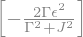

In [47]:
i=0
j=0
(nullspace[i].transpose().conjugate()*(          -1*(Q*L1*P).conjugate().transpose()*(Q*L0*Q).pinv()*Q*L1*P      )*nullspace[j]).simplify(deep=True)

In [50]:
(nullspace[i].transpose().conjugate()*(          -1*(P*L1*Q).conjugate()*(Q*L0*Q).pinv()*Q*L1*P      )*nullspace[j]).simplify(deep=True)

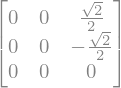

In [66]:
def Hilbert_inner_product(a, b):
    return sp.Trace( a.conjugate().transpose() * b ).doit()

def euclidean(i):
    return sp.Matrix(N, 1, lambda k,l: 1 if (i-1)==k else 0)

def outer_product(a, b):
    return a * b.conjugate().transpose()

def e(i):
    if i == 1:
        return (outer_product( euclidean(1), euclidean(1) ) + outer_product( euclidean(2), euclidean(2) ))/sp.sqrt(2)
    elif i==2:
        raise ValueError
    else:
        return outer_product( euclidean(i), euclidean(i) )

def c_k(pm,k):
    if k>=3:
        return (outer_product(euclidean(1), euclidean(k)) + pm*outer_product(euclidean(2), euclidean(k)))/sp.sqrt(2)
    else:
        raise ValueError


def c_k_bar(pm,k):
    if k>=3:
        return (outer_product(euclidean(k), euclidean(1)) + pm*outer_product(euclidean(k), euclidean(2)))/sp.sqrt(2)
    else:
        raise ValueError



In [86]:

sp.summation(sp.Symbol("b"), (t,1,10))

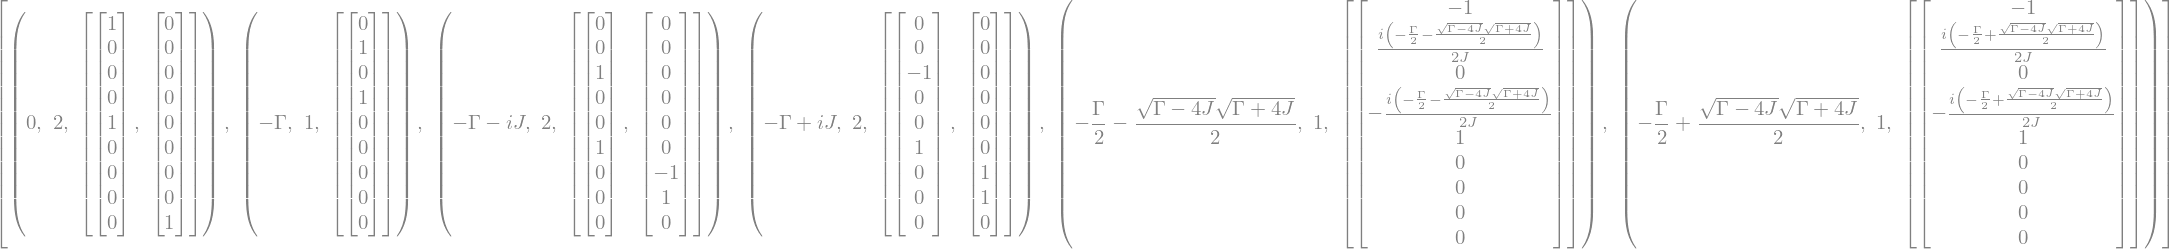

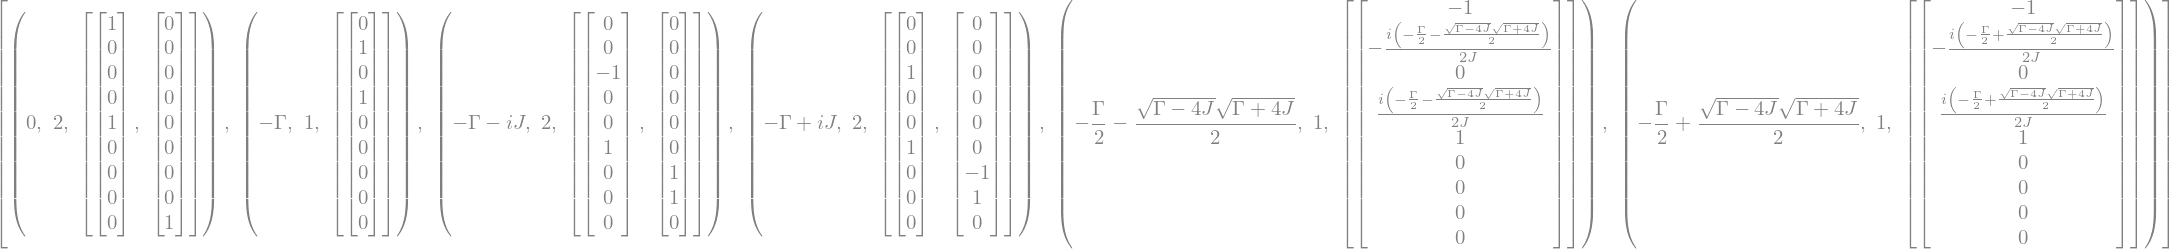

In [10]:
# computing left and right eigenvectors of L0
display(L0.eigenvects()) # right
display(Dagger(L0).eigenvects()) # left

B = L0.eigenvects()

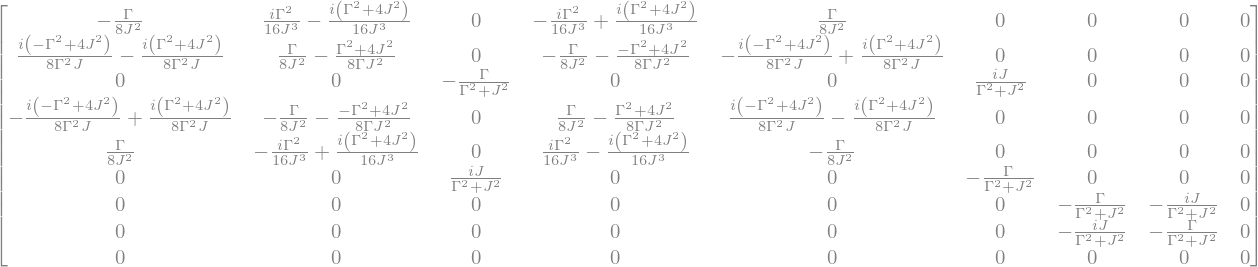

In [105]:
A = Q*L0*Q
S = Q*A.pinv()*Q
S

In [106]:
P1 = -1*P*L1*S - -1*S*L1*P

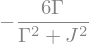

In [107]:
# second order correction

sp.Trace( P*L1*S*L1 ).simplify().together()/-1